In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [68]:
# Load the dataset
df = pd.read_csv('/Users/tamkhong/Downloads/Sleep_health_and_lifestyle_dataset.csv')

# Display rows
df.head()



,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


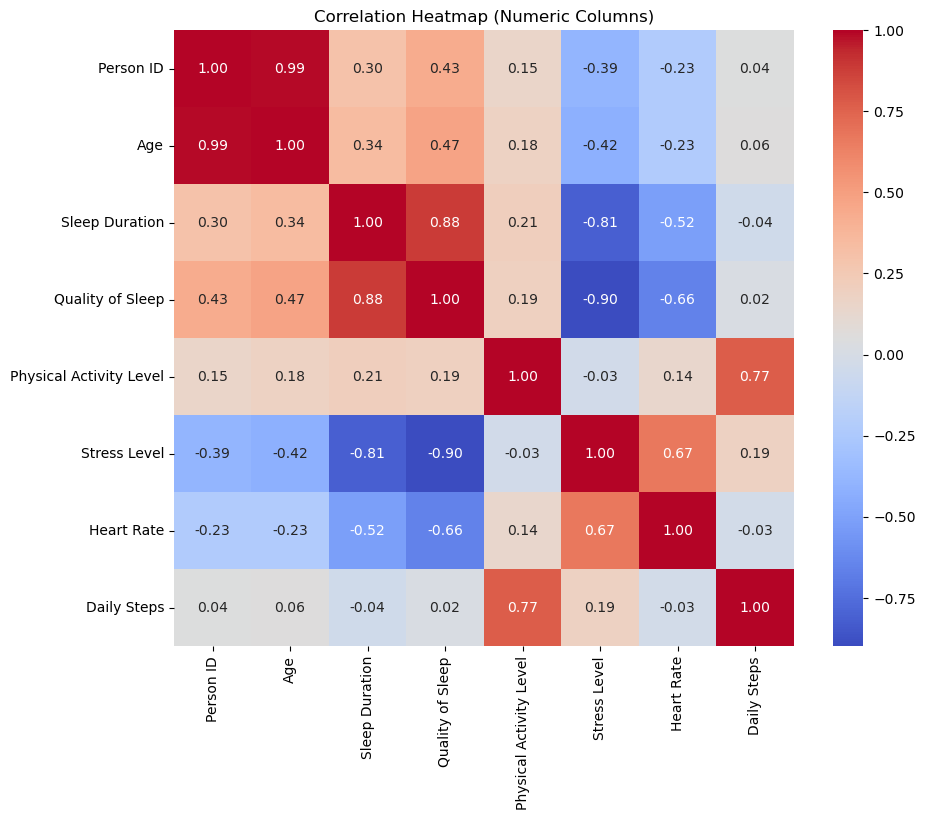

In [72]:
numeric_df = df.select_dtypes(include='number')  # only keep numeric columns
corr = numeric_df.corr()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Columns)")
plt.show()

In [59]:
# Check for missing values
df.isnull().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

In [60]:
#Check data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [61]:
#check how many columns in the dataset
df.shape

(374, 13)

In [62]:
# Check if stress level and quality of sleep from scale 1 to 10
df[~df['Stress Level'].between(1, 10) | ~df['Quality of Sleep'].between(1, 10)]

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder


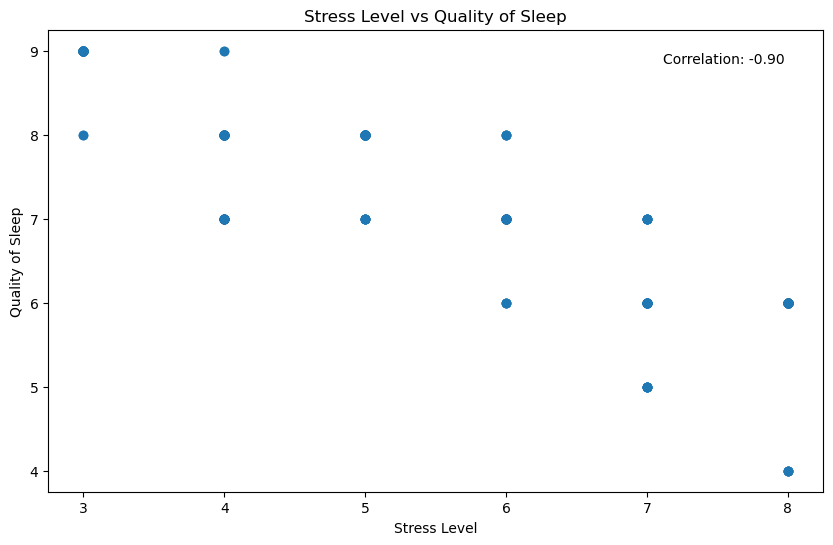

In [63]:

# Calculate correlation
correlation = df['Stress Level'].corr(df['Quality of Sleep'])

# Create scatterplot
plt.figure(figsize=(10,6))
plt.scatter(df['Stress Level'], df['Quality of Sleep'])

plt.title('Stress Level vs Quality of Sleep')
plt.xlabel('Stress Level')
plt.ylabel('Quality of Sleep')

# Add correlation text (top right)
plt.text(
    0.95, 0.95,
    f'Correlation: {correlation:.2f}',
    transform=plt.gca().transAxes,
    horizontalalignment='right',
    verticalalignment='top'
)

plt.show()


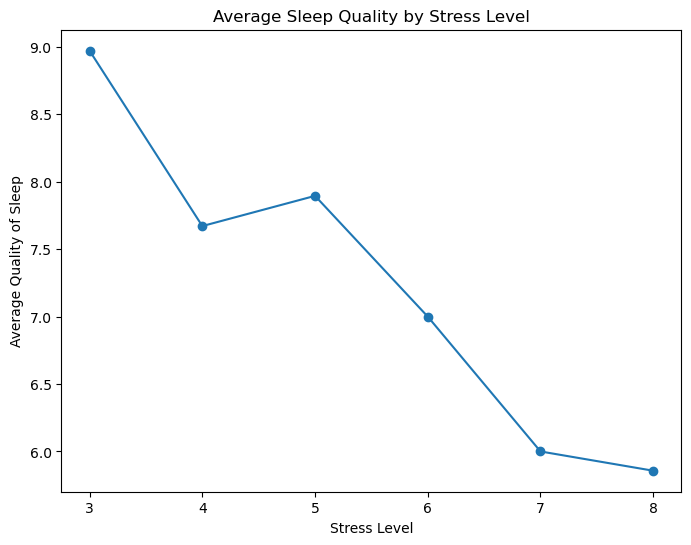

In [64]:
# Calculate mean quality of sleep for each stress level
mean_values = df.groupby('Stress Level')['Quality of Sleep'].mean()

plt.figure(figsize=(8,6))
mean_values.plot(marker='o')
plt.title('Average Sleep Quality by Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Average Quality of Sleep')
plt.show()